# RF / SHAP feature-selection analysis

Per contagion threshold, selects a robust feature set and trains an RF
regressor on spread size (`fraction_above_x`).

**Selection logic** (run once per seed in `SEEDS`):
1. Rank all features by SHAP importance.
2. Cluster features by correlation (`|r| >= CORR_THRESHOLD` => same cluster).
3. Keep the most important feature in each cluster.

**Outputs**, per `threshold_<tv>/`:
- aggregates across seeds (the point of running many seeds):
  - `selection_frequency.csv` / `.png` -- how often each feature is kept
  - `shap_importance.csv` -- mean(|SHAP|) over seeds
  - `univariate_scores.csv` / `.png` -- standalone CV R² + MI per feature
  - `ablation_curve.csv` / `.png` -- CV R² vs #features (most-important first)
- per seed, under `threshold_<tv>/seed_<sd>/` (this seed's own full set):
  - `cluster_keep.png` -- dendrogram + importance, kept marked
  - `ignition_pairs.png` -- observed spread over the top-3 features, as three pairwise 2-D scatters
  - `ablation_curve.csv` / `.png` -- this seed's CV R² vs #features
  - `univariate_scores.csv` / `.png` -- this seed's standalone CV R² + MI
  - `shap_importance.csv` -- this seed's mean(|SHAP|)
  - `decorr_shap_beeswarm.png` -- SHAP beeswarm on the kept set

Run cells top to bottom. Everything still saves to disk exactly like the
script version -- nothing here changes the actual analysis, only how you
run it.


## Imports

In [2]:
import json
import warnings
from pathlib import Path
import random 
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
import shap
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor

import os
os.environ["PIPELINE_SCALE"] = "0.10"  # Limit the number of threads used by OpenMP to 1
warnings.filterwarnings("ignore")
import data_lake as dl

# from diffusion_contract import RF_KWARGS, RUN_MANIFEST_FILENAME, THRESHOLD_COL


c:\Users\gulpenk\Documents\PhD projects\HPC\hpc_create_networks\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
"""Drop-in for the two smf.ols calls -- numpy + scipy only, no statsmodels."""

from itertools import combinations

import numpy as np
import pandas as pd
from scipy import stats


def ols_effects(y: pd.Series, X: pd.DataFrame, interactions: bool = True):
    """0/1 coded OLS, same parameterisation as `y ~ a * b * c` in statsmodels.

    Returns (r2, eff) where eff is a DataFrame indexed by term with coef and p.
    """
    cols = list(X.columns)
    terms, names = [], []
    for r in range(1, (len(cols) if interactions else 1) + 1):
        for combo in combinations(cols, r):
            terms.append(X[list(combo)].prod(axis=1).to_numpy(dtype=float))
            names.append(":".join(combo))

    A = np.column_stack([np.ones(len(X))] + terms)
    yv = y.to_numpy(dtype=float)
    n, p = A.shape

    coef, *_ = np.linalg.lstsq(A, yv, rcond=None)
    resid = yv - A @ coef
    sse = float(resid @ resid)
    sst = float(((yv - yv.mean()) ** 2).sum())
    mse = sse / (n - p)
    se = np.sqrt(np.diag(np.linalg.pinv(A.T @ A)) * mse)

    with np.errstate(divide="ignore", invalid="ignore"):
        t = coef / se
    eff = pd.DataFrame(
        {"coef": coef[1:], "p": 2 * stats.t.sf(np.abs(t[1:]), n - p)},
        index=names,
    )
    return (1 - sse / sst if sst else np.nan), eff

## Config

In [ ]:
thresholds = [0.2, 0.3]

ABLATION_PATH = (dl.ROOT /"analysis"/"topology_diffusion"/"rf_shap_analysis"/"werkschool"/"topology_to_diffusion")

for threshold in thresholds:
    df = pd.read_csv(dl.ROOT /"analysis"/"topology_diffusion"/"rf_shap_analysis"/"werkschool"/"topology_to_diffusion"/f"threshold_{threshold}")

In [4]:
SEEDS = [42, 7, 13, 21, 101]
PARQUET_PATH = (dl.ROOT / "analysis_tables" / "full_table.parquet")
PARQUET_PATH1 = (dl.ROOT / "analysis_tables" / "full_table1.parquet")

# WERKSCHOOL
# detected_community_density_by_size_inter_skew,0.02662609067969631
# detected_community_edges_intra_skew,0.029424176404375817
# detected_community_density_by_size_intra_std,0.04245538530219834
# coreness_std,0.07214217859641454

# BUREN
# coreness_std,0.033890318450889495
# detected_community_edges_inter_skew,0.038390375493326453
# coreness_mean,0.04170751411277437

TARGET_COL = "detected_community_edges_inter_mean"
TARGET_SCALE = 100
MIN_SLICE = 100
CORR_THRESHOLD = 0.8       # |r| at/above which features share a cluster
ABLATION_CV = 5     
THRESHOLD_COL = "threshold_value"
LAYER = "buren"
         # folds for CV scores
RF_KWARGS = dict(
    n_estimators=100,
    max_depth=12,          # caps SHAP's depth² blowup
    min_samples_leaf=20,   # fewer, larger leaves → fewer paths to enumerate
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
)
IGNITE_CMAP = LinearSegmentedColormap.from_list(
    "ignite", ["#0b1f3a", "#1d4ed8", "#f59e0b", "#dc2626"])



## Model helpers

In [5]:
def rf(seed, **kw):
    """A fresh RF with the shared kwargs + this seed."""
    return XGBRegressor(n_estimators=100, max_depth=12, learning_rate=0.1)
    # return RandomForestRegressor(**{**RF_KWARGS, "random_state": seed}, **kw)


def cv_r2(X, y, seed):
    return float(cross_val_score(rf(seed), X, y, cv=ABLATION_CV, scoring="r2").mean())


## Feature selection: SHAP importance + correlation clustering

In [6]:
def shap_importance(X, y, seed):
    """mean(|SHAP|) per feature for an RF fit with this seed."""
    sv = shap.TreeExplainer(rf(seed).fit(X, y))(X, check_additivity=False)
    vals = sv.values[:, :, 0] if sv.values.ndim == 3 else sv.values
    return pd.Series(np.abs(vals).mean(0), index=X.columns)


def cluster_keep(X, importance, out_png):
    """Cluster features by |corr| and keep the most important per cluster.
    Saves a dendrogram + importance-bar figure. Returns the kept feature list."""
    good = X.nunique()[lambda s: s > 1].index.tolist()
    constant = [c for c in X.columns if c not in good]

    # if fewer than 2 varying features, there's nothing to cluster — keep everything
    if len(good) < 2:
        print(f"[cluster_keep] {len(good)} varying feature(s); "
              f"keeping all {len(X.columns)} columns unclustered.")
        return sorted(set(X.columns))

    X = X[good]
    corr = X.corr().abs()
    dist = np.clip(1 - np.nan_to_num(corr.values, nan=0.0), 0.0, None)
    np.fill_diagonal(dist, 0.0)
    Z = linkage(squareform(dist, checks=False), method="average")
    cut = 1 - CORR_THRESHOLD
    clusters = fcluster(Z, t=cut, criterion="distance")

    info = pd.DataFrame({"feature": good, "cluster": clusters,
                         "imp": importance[good].values})
    kept = set(info.sort_values("imp", ascending=False)
               .groupby("cluster").first()["feature"])

    palette = plt.cm.tab10(np.linspace(0, 1, 10))
    cl_color = {c: matplotlib.colors.to_hex(palette[i % 10])
                for i, c in enumerate(sorted(set(clusters)))}
    feat_cluster = dict(zip(info["feature"], info["cluster"]))

    fig, (axd, axb) = plt.subplots(
        1, 2, figsize=(13, max(5, 0.55 * len(good))),
        gridspec_kw={"width_ratios": [3, 1.2], "wspace": 0.5})

    n = Z.shape[0] + 1

    def link_color(k):
        stack, leaves = [k], []
        while stack:
            node = stack.pop()
            if node < n:
                leaves.append(node)
            else:
                stack += [int(Z[node - n, 0]), int(Z[node - n, 1])]
        cls = {clusters[i] for i in leaves}
        return cl_color[cls.pop()] if len(cls) == 1 else "#9ca3af"

    dend = dendrogram(Z, labels=good, orientation="left", ax=axd,
                      link_color_func=link_color, no_labels=True)
    axd.axvline(cut, color="#dc2626", ls="--", lw=1.6,
                label=f"cut = 1 - corr_threshold = {cut:.2f}")

    leaf_y = {f: i * 10 + 5 for i, f in enumerate(dend["ivl"])}
    axd.set_yticks(list(leaf_y.values()))
    axd.set_yticklabels([])
    for fname, y in leaf_y.items():
        if fname in kept:
            txt, color, weight = "\u2605 " + fname[4:], cl_color[feat_cluster[fname]], "bold"
        else:
            txt, color, weight = "\u2717 " + fname[4:], "#9ca3af", "normal"
        axd.text(-0.01, y, txt, ha="right", va="center", fontsize=9,
                 color=color, fontweight=weight,
                 transform=axd.get_yaxis_transform())
    axd.set_xlabel("distance  (1 - |correlation|)")
    axd.set_title(f"cluster_keep  (corr_threshold = {CORR_THRESHOLD})\n"
                  f"{len(good)} features \u2192 {len(set(clusters))} clusters; "
                  f"\u2605 = kept (highest importance per cluster)", fontsize=11)
    axd.legend(loc="upper left", fontsize=9)

    axb.set_ylim(axd.get_ylim())
    for fname, y in leaf_y.items():
        base = cl_color[feat_cluster[fname]]
        keep_it = fname in kept
        axb.barh(y, importance[fname], height=6, color=base,
                 alpha=1.0 if keep_it else 0.32)
        if keep_it:
            axb.annotate("\u2605", (importance[fname], y), xytext=(3, 0),
                         textcoords="offset points", va="center",
                         fontsize=11, color=base)
    axb.set_yticks([])
    axb.set_xlabel("mean(|SHAP|)")
    axb.set_title("importance\n(\u2605 = kept; faded = dropped)", fontsize=10)

    fig.savefig(out_png, dpi=130, bbox_inches="tight")
    plt.close(fig)
    return sorted(kept)




## Per-seed evaluation metrics

In [7]:
def ablate(X, y, kept, importance, seed):
    """Forward build on the kept set, most-important first. One row per step."""
    ordered = importance[kept].sort_values(ascending=False).index.tolist()
    print(ordered)
    ordered = importance[kept].sort_values(ascending=False).index.tolist()[:10]
    print(ordered)

    rows, prev = [], None
    for k in range(1, len(ordered) + 1):
        score = cv_r2(X[ordered[:k]], y, seed)
        rows.append({"n_features": k, "cv_score": score,
                     "added_feature": ordered[k - 1],
                     "delta": None if prev is None else score - prev})
        prev = score
    return rows


def baselines(X, y, importance, seed):
    """Dummy (mean predictor) and single-best-feature reference scores."""
    best_feat = importance.sort_values(ascending=False).index[0]
    return {"dummy_r2": float(cross_val_score(
                DummyRegressor(strategy="mean"), X, y,
                cv=ABLATION_CV, scoring="r2").mean()),
            "best1_r2": cv_r2(X[[best_feat]], y, seed),
            "best1_feat": best_feat}


def univariate(X, y, kept, seed):
    """Per-feature standalone CV R^2 and mutual information (on the kept set)."""
    kept = list(kept)
    
    mi = mutual_info_regression(X[kept].values, y.values, random_state=seed)
    return pd.DataFrame({"feature": kept,
                         "uni_r2": [cv_r2(X[[c]], y, seed) for c in kept],
                         "mi": mi})


## Per-seed plots

In [8]:
def ignition_plots(X, y, importance, kept, seed, seed_dir):
    """Observed spread over the top-3 features, shown as the three pairwise
    2-D scatters (f1xf2, f1xf3, f2xf3). Pure data -- colour is observed spread."""
    ordered = importance[kept].sort_values(ascending=False).index.tolist()
    yv = np.asarray(y)
    vmin, vmax = yv.min(), yv.max()
    if len(ordered) > 2:
        top = ordered[:3]
        pairs = [(top[0], top[1]), (top[0], top[2]), (top[1], top[2])]
        

        fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
        sc = None
        for ax, (fx, fy) in zip(axes, pairs):
            sc = ax.scatter(X[fx], X[fy], c=yv, cmap=IGNITE_CMAP, vmin=vmin, vmax=vmax,
                            s=38, edgecolors="#333", linewidths=0.4)
            ax.set_xlabel(fx[4:]); ax.set_ylabel(fy[4:])
            ax.set_title(f"{fx[4:]}  vs  {fy[4:]}", fontsize=11)
        fig.colorbar(sc, ax=axes, label="observed spread (fraction_above_x)",
                    fraction=0.025, pad=0.01)
        fig.suptitle("Observed spread across the top-3 features "
                    "(three pairwise views)", fontsize=13)
        fig.savefig(seed_dir / "ignition_pairs.png", dpi=130, bbox_inches="tight")
        plt.close(fig)


def beeswarm(X, y, kept, seed, out_png):
    """SHAP beeswarm on the kept (de-correlated) set."""
    sv = shap.TreeExplainer(rf(seed).fit(X[kept], y))(X[kept], check_additivity=False)
    if sv.values.ndim == 3:
        sv = sv[:, :, 0]
    plt.figure(figsize=(10, 8))
    shap.summary_plot(sv, X[kept], plot_type="dot", show=False,
                      plot_size=None, max_display=20)
    plt.title(f"SHAP beeswarm (de-correlated set, seed {seed})", fontsize=12)
    plt.tight_layout(); plt.savefig(out_png, dpi=120); plt.close()


def plot_seed_ablation(abl, base, out_png):
    """Single-seed feature build-up curve: this seed's CV R^2 vs #features
    (most-important first), with its dummy and single-best baselines, each
    point labelled with the feature added. No std band -- it's one seed."""
    df = pd.DataFrame(abl).sort_values("n_features")
    plt.figure(figsize=(10, 6))
    plt.plot(df["n_features"], df["cv_score"], marker="o", color="#2563eb",
             lw=2, label="CV R^2")
    plt.axhline(base["dummy_r2"], color="#dc2626", ls="--", lw=1.5,
                label=f"dummy (mean predictor): R^2={base['dummy_r2']:.3f}")
    plt.axhline(base["best1_r2"], color="#16a34a", ls=":", lw=1.5,
                label=f"single best feature ({base['best1_feat'][4:]}): "
                      f"R^2={base['best1_r2']:.3f}")
    for _, r in df.iterrows():
        plt.annotate(r["added_feature"][4:], (r["n_features"], r["cv_score"]),
                     textcoords="offset points", xytext=(0, 9), ha="center",
                     fontsize=7, rotation=35, color="#374151")
    plt.xlabel("Number of features (most-important added first; "
               "label = feature added)")
    plt.ylabel("CV R^2  (higher = better)")
    plt.title("Feature build-up (most-important added first)\n"
              "leftmost point = single most important feature")
    plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
    plt.savefig(out_png, dpi=130); plt.close()


def plot_seed_univariate(uni, out_png):
    """Single-seed univariate predictive power: this seed's standalone CV R^2
    per feature, sorted."""
    u = uni.sort_values("uni_r2", ascending=False).head(30)[::-1]
    plt.figure(figsize=(8, max(4, 0.32 * len(u))))
    plt.barh([f[4:] for f in u["feature"]], u["uni_r2"], color="#7c3aed")
    plt.axvline(0, color="#6b7280", lw=0.8)
    plt.xlabel("CV R^2 of an RF on this feature ALONE")
    plt.title("Univariate predictive power per feature\n"
              "(how well each feature predicts the target on its own)")
    plt.tight_layout(); plt.savefig(out_png, dpi=130); plt.close()


## Per-seed pipeline

In [9]:
def select_once(X, y, seed, seed_dir):
    """All per-seed work for one seed; writes that seed's full set of outputs
    (plots + CSVs) to seed_dir."""
    seed_dir.mkdir(parents=True, exist_ok=True)
    print(f"=== seed {seed} ===")
    print("=== shap importance ===")
    imp = shap_importance(X, y, seed)
    print("=== cluster keep ===")
    kept = cluster_keep(X, imp, seed_dir / "cluster_keep.png")
   #  kept = imp
    imp = shap_importance(X[kept], y, seed)                 # 3. re-rank the survivors
    print("=== ablation ===")
    abl = ablate(X, y, kept, imp, seed)
    print("=== baselines ===")
    base = baselines(X, y, imp, seed)
    uni = univariate(X, y, kept, seed)

    # this seed's own plots + CSVs
    ignition_plots(X, y, imp, kept, seed, seed_dir)
    beeswarm(X, y, kept, seed, seed_dir / "decorr_shap_beeswarm.png")
    plot_seed_ablation(abl, base, seed_dir / "ablation_curve.png")
    plot_seed_univariate(uni, seed_dir / "univariate_scores.png")
    imp.reindex(imp.sort_values(ascending=False).index).rename("mean_abs_shap") \
       .to_csv(seed_dir / "shap_importance.csv")
    pd.DataFrame(abl).to_csv(seed_dir / "ablation_curve.csv", index=False)
    uni.sort_values("uni_r2", ascending=False) \
       .to_csv(seed_dir / "univariate_scores.csv", index=False)

    return kept, imp, abl, base, uni


## Cross-seed aggregation

In [10]:
def run_slice(X, y, outdir):
    """Run all seeds; write per-seed plots under seed_<sd>/ and cross-seed
    aggregates at outdir root."""
    kept_counts = pd.Series(0.0, index=X.columns)
    imp_sum = pd.Series(0.0, index=X.columns)
    abl_rows, base_rows, uni_rows = [], [], []

    for sd in SEEDS:
        kept, imp, abl, base, uni = select_once(X, y, sd, outdir / f"seed_{sd}")
        kept_counts[kept] += 1
        imp_sum += imp
        abl_rows += [{**r, "seed": sd} for r in abl]
        base_rows.append({**base, "seed": sd})
        uni_rows.append(uni.assign(seed=sd))
        print(f"    seed {sd}: kept {len(kept)}/{X.shape[1]}")

    freq = (kept_counts / len(SEEDS)).sort_values(ascending=False)
    imp_mean = (imp_sum / len(SEEDS)).reindex(freq.index)
    freq.rename("selection_freq").to_csv(outdir / "selection_frequency.csv")
    imp_mean.rename("mean_abs_shap").to_csv(outdir / "shap_importance.csv")

    _plot_selection_freq(freq, outdir / "selection_frequency.png")
    uni_agg = _aggregate_univariate(uni_rows, outdir)
    curve, base_df = _aggregate_ablation(abl_rows, base_rows, outdir)

    best = curve.loc[curve["mean"].idxmax()]
    return {"n_always_kept": int((freq == 1).sum()),
            "top_features": freq.head(10).round(3).to_dict(),
            "best_cv_r2": round(float(best["mean"]), 4),
            "best_n_features": int(best["n_features"]),
            "dummy_r2": round(float(base_df["dummy_r2"].mean()), 4),
            "best1_r2": round(float(base_df["best1_r2"].mean()), 4),
            "best1_feature": base_df["best1_feat"].mode().iloc[0],
            "top_univariate": {r["feature"]: round(r["uni_r2_mean"], 3)
                               for _, r in uni_agg.head(5).iterrows()}
            }


def _plot_selection_freq(freq, out_png):
    top = freq.head(30)[::-1]
    plt.figure(figsize=(8, max(4, 0.32 * len(top))))
    plt.barh([f[4:] for f in top.index], top.values,
             color=["#2563eb" if v == 1 else "#93c5fd" for v in top.values])
    plt.xlabel(f"Fraction of {len(SEEDS)} seeds that kept the feature")
    plt.title("Feature selection frequency across seeds")
    plt.xlim(0, 1); plt.tight_layout(); plt.savefig(out_png, dpi=130); plt.close()


def _aggregate_univariate(uni_rows, outdir):
    uni_agg = (pd.concat(uni_rows, ignore_index=True).groupby("feature")
               .agg(uni_r2_mean=("uni_r2", "mean"), uni_r2_std=("uni_r2", "std"),
                    mi_mean=("mi", "mean"))
               .reset_index().sort_values("uni_r2_mean", ascending=False))
    uni_agg["uni_r2_std"] = uni_agg["uni_r2_std"].fillna(0.0)
    uni_agg.to_csv(outdir / "univariate_scores.csv", index=False)

    u = uni_agg.head(30)[::-1]
    plt.figure(figsize=(8, max(4, 0.32 * len(u))))
    plt.barh([f[4:] for f in u["feature"]], u["uni_r2_mean"],
             xerr=u["uni_r2_std"], color="#7c3aed",
             error_kw={"ecolor": "#c4b5fd", "elinewidth": 1})
    plt.axvline(0, color="#6b7280", lw=0.8)
    plt.xlabel("CV R^2 of an RF on this feature ALONE  (mean +/- std over seeds)")
    plt.title("Univariate predictive power per feature\n"
              "(how well each feature predicts the target on its own)")
    plt.tight_layout(); plt.savefig(outdir / "univariate_scores.png", dpi=130)
    plt.close()
    return uni_agg


def _aggregate_ablation(abl_rows, base_rows, outdir):
    abl_df = pd.DataFrame(abl_rows)

    def mode_agree(s):
        vc = s.dropna().value_counts()
        if vc.empty:
            return pd.Series({"added_mode": None, "added_agree": 0.0})
        return pd.Series({"added_mode": vc.index[0], "added_agree": vc.iloc[0] / len(s)})

    score_agg = abl_df.groupby("n_features")["cv_score"].agg(["mean", "std", "count"])
    delta_agg = abl_df.groupby("n_features")["delta"].mean().rename("delta_mean")
    add_agg = abl_df.groupby("n_features")["added_feature"].apply(mode_agree).unstack()
    curve = (score_agg.join(delta_agg).join(add_agg)
             .reset_index().sort_values("n_features"))
    curve["std"] = curve["std"].fillna(0.0)
    curve.to_csv(outdir / "ablation_curve.csv", index=False)

    base_df = pd.DataFrame(base_rows)
    dummy_mean = base_df["dummy_r2"].mean()
    best1_mean = base_df["best1_r2"].mean()
    best1_feat = base_df["best1_feat"].mode().iloc[0]

    plt.figure(figsize=(10, 6))
    for _, g in abl_df.groupby("seed"):
        g = g.sort_values("n_features")
        plt.plot(g["n_features"], g["cv_score"], color="#9ca3af", alpha=0.35, lw=1)
    plt.fill_between(curve["n_features"], curve["mean"] - curve["std"],
                     curve["mean"] + curve["std"], color="#2563eb", alpha=0.18,
                     label="+/- 1 std across seeds")
    plt.plot(curve["n_features"], curve["mean"], marker="o", color="#2563eb",
             lw=2, label="mean across seeds")
    plt.axhline(dummy_mean, color="#dc2626", ls="--", lw=1.5,
                label=f"dummy (mean predictor): R^2={dummy_mean:.3f}")
    plt.axhline(best1_mean, color="#16a34a", ls=":", lw=1.5,
                label=f"single best feature ({best1_feat[4:]}): R^2={best1_mean:.3f}")
    for _, r in curve.iterrows():
        if pd.notna(r["added_mode"]):
            star = "" if r["added_agree"] == 1 else "*"
            plt.annotate(r["added_mode"][4:] + star, (r["n_features"], r["mean"]),
                         textcoords="offset points", xytext=(0, 9), ha="center",
                         fontsize=7, rotation=35, color="#374151")
    plt.xlabel("Number of features (most-important added first; label = feature added)")
    plt.ylabel("CV R^2  (higher = better)")
    plt.title("Feature build-up (most-important added first)\n"
              "leftmost point = single most important feature; "
              "* = seeds added different features")
    plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
    plt.savefig(outdir / "ablation_curve.png", dpi=130); plt.close()
    return curve, base_df


In [11]:
import pandas as pd
from collections import defaultdict

def collapse_layers(df, layers, id_col="network_id"):
    def token_from_id(v):
        return v.split("__")[-1]

    def split_col(col):
        segs = col.split("_")
        for layer in layers:
            if layer in segs:                     # whole-segment match
                generic = "_".join(s for s in segs if s != layer)
                return layer, generic
        return None, None

    # classify every column: does it parse to a known layer, or not?
    parsed = {c: split_col(c) for c in df.columns if c != id_col}
    layer_feature_cols = [c for c, (l, _) in parsed.items() if l is not None]
    passthrough_cols   = [c for c in df.columns
                          if c != id_col and c not in layer_feature_cols]

    by_generic = defaultdict(dict)
    for col in layer_feature_cols:
        layer, generic = parsed[col]
        by_generic[generic][layer] = col

    row_token = df[id_col].map(token_from_id)

    out = df[[id_col] + passthrough_cols].copy()   # id + all non-layer cols, as-is
    out["layer"] = row_token.values

    for generic, layer_map in by_generic.items():
        s = pd.Series(index=df.index, dtype="float64")
        for layer, col in layer_map.items():
            rows = row_token == layer
            s.loc[rows] = df.loc[rows, col]
        out[generic] = s

    return out

## Run per threshold

In [12]:
PARQUET_PATH

WindowsPath('C:/Users/gulpenk/Documents/PhD projects/HPC/hpc_create_networks/data_lake_scale0.10/analysis_tables/full_table.parquet')

Loading CSV...
                                              network_id  threshold_idx  \
0                   sample_00109__lft_oplniv__werkschool              0   
3            sample_00029__etngrp_lft_oplniv__werkschool              0   
4                   sample_00284__etngrp_lft__werkschool              0   
7                          sample_00104__lft__werkschool              0   
9                     sample_00171__geslacht__werkschool              0   
...                                                  ...            ...   
13484  sample_00172__etngrp_geslacht_lft_oplniv__werk...              0   
13485                   sample_00140__oplniv__werkschool              0   
13489                 sample_00254__geslacht__werkschool              0   
13497  sample_00274__etngrp_geslacht_lft_oplniv__werk...              0   
13498      sample_00119__etngrp_geslacht_lft__werkschool              0   

       threshold_value  n_simulations  total_nodes  ignition_probability_50  \
0    

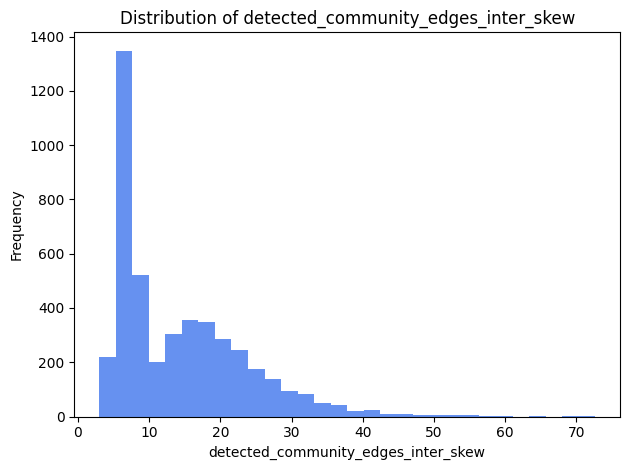

['hhi', 'familie', 'huishouden', 'buren']
['mix_werkschool_etngrp_homophily_coleman', 'mix_werkschool_etngrp_homophily_coleman_mean', 'mix_werkschool_etngrp_homophily_coleman_std', 'mix_werkschool_etngrp_homophily_expected', 'mix_werkschool_etngrp_homophily_raw', 'mix_werkschool_geslacht_homophily_coleman', 'mix_werkschool_geslacht_homophily_coleman_mean', 'mix_werkschool_geslacht_homophily_coleman_std', 'mix_werkschool_geslacht_homophily_expected', 'mix_werkschool_geslacht_homophily_raw', 'mix_werkschool_lft_homophily_coleman', 'mix_werkschool_lft_homophily_coleman_mean', 'mix_werkschool_lft_homophily_coleman_std', 'mix_werkschool_lft_homophily_expected', 'mix_werkschool_lft_homophily_raw', 'mix_werkschool_oplniv_homophily_coleman', 'mix_werkschool_oplniv_homophily_coleman_mean', 'mix_werkschool_oplniv_homophily_coleman_std', 'mix_werkschool_oplniv_homophily_expected', 'mix_werkschool_oplniv_homophily_raw']
mix_werkschool_etngrp_homophily_coleman           1
mix_werkschool_etngrp_homo

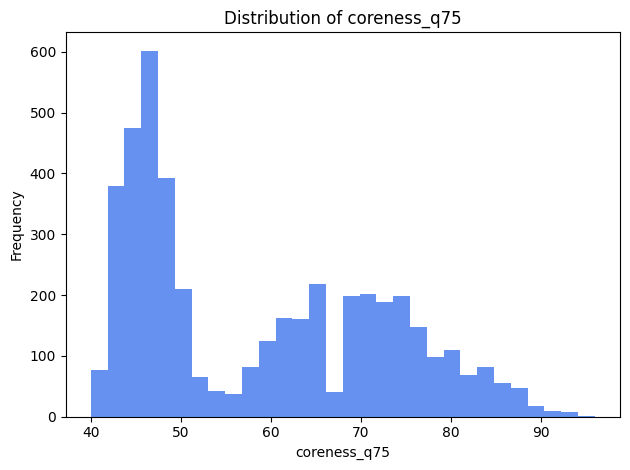

['hhi', 'familie', 'huishouden', 'buren']
['mix_werkschool_etngrp_homophily_coleman', 'mix_werkschool_etngrp_homophily_coleman_mean', 'mix_werkschool_etngrp_homophily_coleman_std', 'mix_werkschool_etngrp_homophily_expected', 'mix_werkschool_etngrp_homophily_raw', 'mix_werkschool_geslacht_homophily_coleman', 'mix_werkschool_geslacht_homophily_coleman_mean', 'mix_werkschool_geslacht_homophily_coleman_std', 'mix_werkschool_geslacht_homophily_expected', 'mix_werkschool_geslacht_homophily_raw', 'mix_werkschool_lft_homophily_coleman', 'mix_werkschool_lft_homophily_coleman_mean', 'mix_werkschool_lft_homophily_coleman_std', 'mix_werkschool_lft_homophily_expected', 'mix_werkschool_lft_homophily_raw', 'mix_werkschool_oplniv_homophily_coleman', 'mix_werkschool_oplniv_homophily_coleman_mean', 'mix_werkschool_oplniv_homophily_coleman_std', 'mix_werkschool_oplniv_homophily_expected', 'mix_werkschool_oplniv_homophily_raw']
mix_werkschool_etngrp_homophily_coleman           1
mix_werkschool_etngrp_homo

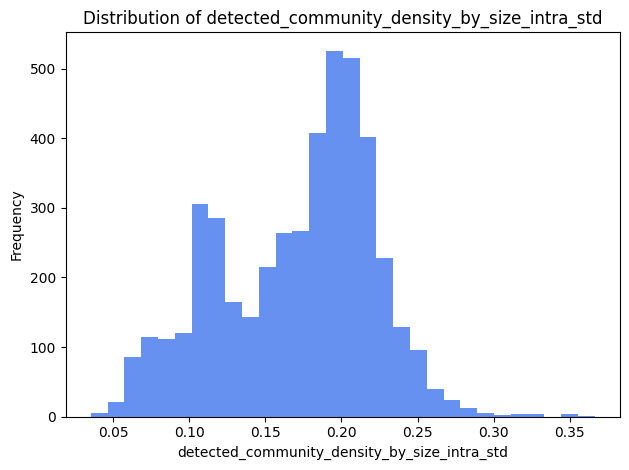

['hhi', 'familie', 'huishouden', 'buren']
['mix_werkschool_etngrp_homophily_coleman', 'mix_werkschool_etngrp_homophily_coleman_mean', 'mix_werkschool_etngrp_homophily_coleman_std', 'mix_werkschool_etngrp_homophily_expected', 'mix_werkschool_etngrp_homophily_raw', 'mix_werkschool_geslacht_homophily_coleman', 'mix_werkschool_geslacht_homophily_coleman_mean', 'mix_werkschool_geslacht_homophily_coleman_std', 'mix_werkschool_geslacht_homophily_expected', 'mix_werkschool_geslacht_homophily_raw', 'mix_werkschool_lft_homophily_coleman', 'mix_werkschool_lft_homophily_coleman_mean', 'mix_werkschool_lft_homophily_coleman_std', 'mix_werkschool_lft_homophily_expected', 'mix_werkschool_lft_homophily_raw', 'mix_werkschool_oplniv_homophily_coleman', 'mix_werkschool_oplniv_homophily_coleman_mean', 'mix_werkschool_oplniv_homophily_coleman_std', 'mix_werkschool_oplniv_homophily_expected', 'mix_werkschool_oplniv_homophily_raw']
mix_werkschool_etngrp_homophily_coleman           1
mix_werkschool_etngrp_homo

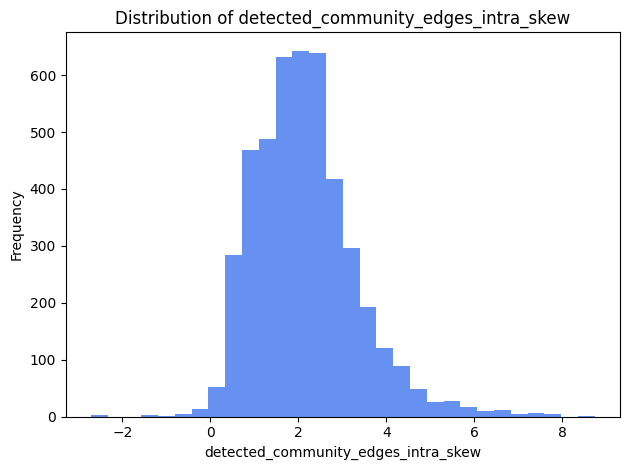

['hhi', 'familie', 'huishouden', 'buren']
['mix_werkschool_etngrp_homophily_coleman', 'mix_werkschool_etngrp_homophily_coleman_mean', 'mix_werkschool_etngrp_homophily_coleman_std', 'mix_werkschool_etngrp_homophily_expected', 'mix_werkschool_etngrp_homophily_raw', 'mix_werkschool_geslacht_homophily_coleman', 'mix_werkschool_geslacht_homophily_coleman_mean', 'mix_werkschool_geslacht_homophily_coleman_std', 'mix_werkschool_geslacht_homophily_expected', 'mix_werkschool_geslacht_homophily_raw', 'mix_werkschool_lft_homophily_coleman', 'mix_werkschool_lft_homophily_coleman_mean', 'mix_werkschool_lft_homophily_coleman_std', 'mix_werkschool_lft_homophily_expected', 'mix_werkschool_lft_homophily_raw', 'mix_werkschool_oplniv_homophily_coleman', 'mix_werkschool_oplniv_homophily_coleman_mean', 'mix_werkschool_oplniv_homophily_coleman_std', 'mix_werkschool_oplniv_homophily_expected', 'mix_werkschool_oplniv_homophily_raw']
mix_werkschool_etngrp_homophily_coleman           1
mix_werkschool_etngrp_homo

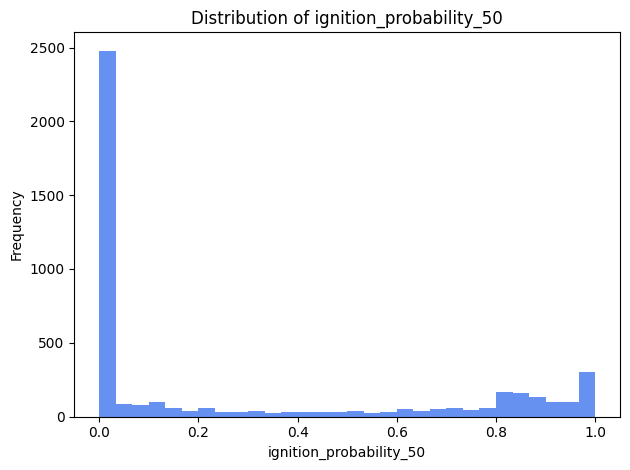

['hhi', 'familie', 'huishouden', 'buren']
['mix_werkschool_etngrp_homophily_coleman', 'mix_werkschool_etngrp_homophily_coleman_mean', 'mix_werkschool_etngrp_homophily_coleman_std', 'mix_werkschool_etngrp_homophily_expected', 'mix_werkschool_etngrp_homophily_raw', 'mix_werkschool_geslacht_homophily_coleman', 'mix_werkschool_geslacht_homophily_coleman_mean', 'mix_werkschool_geslacht_homophily_coleman_std', 'mix_werkschool_geslacht_homophily_expected', 'mix_werkschool_geslacht_homophily_raw', 'mix_werkschool_lft_homophily_coleman', 'mix_werkschool_lft_homophily_coleman_mean', 'mix_werkschool_lft_homophily_coleman_std', 'mix_werkschool_lft_homophily_expected', 'mix_werkschool_lft_homophily_raw', 'mix_werkschool_oplniv_homophily_coleman', 'mix_werkschool_oplniv_homophily_coleman_mean', 'mix_werkschool_oplniv_homophily_coleman_std', 'mix_werkschool_oplniv_homophily_expected', 'mix_werkschool_oplniv_homophily_raw']
mix_werkschool_etngrp_homophily_coleman           1
mix_werkschool_etngrp_homo

In [ ]:
print("Loading CSV...")
df = pd.read_parquet(PARQUET_PATH)

LAYERS = ["werkschool", "buren", "familie"]

df = df[df.network_id.str.contains(LAYER)]

for 

if LAYER == "werkschool":
    TARGET_COLS = ["detected_community_edges_intra_q25", "detected_community_edges_intra_skew",
                   "detected_community_density_by_size_intra_std",
                   "detected_community_edges_intra_skew", "ignition_probability_50"]
if LAYER == "buren":
    TARGET_COLS = [
                #    "detected_community_edges_inter_mean", 
                #    "detected_community_n_observed",
                #    "detected_community_edges_inter_std",
                #    "detected_community_edges_inter_skew", 
                   "ignition_probability_50"
                   ]

ATTRS = ["etngrp", "lft", "geslacht", "oplniv"]

for TARGET_COL in TARGET_COLS:
    OUTDIR = dl.ROOT / "analysis" / "topology_diffusion" / "rf_shap_analysis" / LAYER / "mp_to_topology" / TARGET_COL

    outdir = Path(OUTDIR)
    outdir.mkdir(parents=True, exist_ok=True)
    plt.hist(df[TARGET_COL], bins=30, color="#2563eb", alpha=0.7)
    plt.xlabel(f"{TARGET_COL}")
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {TARGET_COL}")
    plt.tight_layout(); plt.savefig(outdir / "target_distribution.png", dpi=130)
    plt.show()

    not_used_layers = ["hhi", "werkschool", "familie", "huishouden", "buren"]
    not_used_layers.remove(LAYER)
    print(not_used_layers)
    # mix columns for this layer, selected by name (not column position)
    mix_cols = [c for c in df.columns
                if c.startswith("mix_") and LAYER in c
                and not any(t in c for t in tuple(not_used_layers))]
    print(mix_cols)

    # 1. build keep from df FIRST, coercing to numeric
    keep = df[[TARGET_COL, THRESHOLD_COL] + mix_cols].apply(pd.to_numeric, errors="coerce")
    keep = keep.dropna(subset=[TARGET_COL])          # drop rows missing the target only

    # 2. a mix column is NaN when that attribute was not used to generate the
    #    network, so missingness IS the design factor. The 5 variants per
    #    attribute (coleman/_mean/_std/expected/raw) go missing together, so
    #    they collapse to one factor each.
    feats = []
    for a in ATTRS:
        cols = [c for c in mix_cols if f"_{a}_" in c]
        if not cols:
            continue
        keep[f"used_{a}"] = keep[cols].notna().any(axis=1).astype(int)
        feats.append(f"used_{a}")

    keep["used_random"] = np.random.randint(0, 2, len(keep))   # negative control
    feats.append("used_random")

    # the continuous values are constant per attribute, so they carry no signal
    print(keep[mix_cols].nunique().to_string())

    keep = keep[[TARGET_COL, THRESHOLD_COL] + feats]
    print(f"{len(feats)} design factors: {feats}")
    print(f"\nTotal rows: {len(keep)}")
    print(keep)

    manifest = {"csv": PARQUET_PATH, "target": TARGET_COL, "seeds": SEEDS, "blocks": {}}

    print(keep[THRESHOLD_COL].unique())
    for tv in sorted(keep[THRESHOLD_COL].unique()):

        sl = keep[keep[THRESHOLD_COL] == tv]
        block_feats = [f for f in feats if sl[f].nunique() > 1]

        if len(sl) < MIN_SLICE or len(block_feats) < 2:
            print(f"[skip] threshold {tv}: N={len(sl)}, {len(block_feats)} feats")
            continue

        bdir = outdir / f"threshold_{tv}"
        bdir.mkdir(parents=True, exist_ok=True)
        print(f"\n{'='*50}\nthreshold {tv} (N={len(sl)})\n{'='*50}")

        # 3. binary factors -> saturated ANOVA instead of RF/SHAP
        r2_full, eff = ols_effects(sl[TARGET_COL], sl[block_feats])
        r2_main, _   = ols_effects(sl[TARGET_COL], sl[block_feats], interactions=False)
        print(f"R2  main {r2_main:.4f} -> saturated {r2_full:.4f}")
        print(eff.sort_values("p").round(4).to_string())
        eff.to_csv(bdir / "anova_effects.csv")

        manifest["blocks"][f"threshold_{tv}"] = {
            "threshold_value": float(tv),
            "n": int(len(sl)),
            "r2_main": float(r2_main),
            "r2_saturated": float(r2_full),
            **run_slice(sl[block_feats], sl[TARGET_COL], bdir)}

    # with open(outdir / "manifest.json", "w") as f:
    #     json.dump(manifest, f, indent=2, default=float)

In [87]:
import numpy as np
import pandas as pd

LAYER = "werkschool"
ATTRS = ["etngrp", "lft", "geslacht", "oplniv"]
TARGET = "detected_community_edges_inter_skew"

df = pd.read_parquet(PARQUET_PATH)
df = df[df.network_id.str.contains(LAYER)]

# a mix column is NaN when that attribute wasn't used to generate the network
for a in ATTRS:
    col = f"mix_{LAYER}_{a}_homophily_coleman"
    df[f"used_{a}"] = df[col].notna().astype(int)

df["used_random"] = np.random.default_rng(0).integers(0, 2, len(df))   # control

d = df[[TARGET] + [f"used_{a}" for a in ATTRS] + ["used_random"]].dropna()
print(f"n = {len(d)}")
print(d.drop(columns=TARGET).mean().round(3))          # factor on-rates


r2_full, eff = ols_effects(sl[TARGET_COL], sl[block_feats])
r2_main, _   = ols_effects(sl[TARGET_COL], sl[block_feats], interactions=False)
print(f"R2  main {r2_main:.4f} -> saturated {r2_full:.4f}")
print(eff.sort_values("p").round(4).to_string())
eff.to_csv(bdir / "anova_effects.csv")

n = 4496
used_etngrp      0.534
used_lft         0.534
used_geslacht    0.533
used_oplniv      0.534
used_random      0.502
dtype: float64
R2  main 0.1242 -> saturated 0.1481
                                                              coef       p
used_etngrp:used_geslacht                                  -0.2667  0.0000
used_etngrp:used_lft:used_oplniv                           -0.2914  0.0000
used_etngrp                                                -0.1190  0.0005
used_geslacht                                               0.1028  0.0028
used_lft:used_geslacht                                     -0.1168  0.0033
used_geslacht:used_oplniv                                  -0.1147  0.0039
used_lft:used_oplniv:used_random                           -0.1629  0.0042
used_etngrp:used_lft:used_geslacht                          0.1513  0.0061
used_oplniv                                                 0.0871  0.0113
used_lft:used_random                                        0.1204  0.0141


## Write manifest

In [88]:
"""
diagnostics.py -- sanity checks to run alongside run_slice().

Answers four questions the current plots leave open:
  1. Is n large enough to support any of this?
  2. Does the RF beat plain OLS/ridge, or is it overkill for a monotone signal?
  3. How much of the R^2 comes from the *_missing indicators rather than the
     actual homophily values?
  4. What does the feature build-up curve look like when the ranking is
     recomputed inside each CV fold (no selection leakage)?

Usage:
    from diagnostics import run_diagnostics
    diag = run_diagnostics(sl[block_feats], sl[TARGET_COL], SEEDS, bdir)
"""

from __future__ import annotations

import json
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


# --------------------------------------------------------------------------
# helpers
# --------------------------------------------------------------------------

def _safe_splits(n_rows: int, n_splits: int = 5) -> int:
    """Never ask for more folds than we have rows (and keep >= 2 per fold)."""
    return max(2, min(n_splits, n_rows // 2))


def _models(seed: int) -> dict:
    return {
        "dummy": DummyRegressor(strategy="mean"),
        "ols": make_pipeline(StandardScaler(), LinearRegression()),
        "ridge": make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 3, 25))),
        "rf": RandomForestRegressor(
            n_estimators=500, min_samples_leaf=2, random_state=seed, n_jobs=-1
        ),
    }


def _cv_r2(model, X: pd.DataFrame, y: pd.Series, seed: int, n_splits: int) -> np.ndarray:
    """Per-fold R^2. Computed manually so folds are identical across models."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    scores = []
    for tr, te in kf.split(X):
        m = model
        m.fit(X.iloc[tr], y.iloc[tr])
        pred = m.predict(X.iloc[te])
        ss_res = float(np.sum((y.iloc[te].to_numpy() - pred) ** 2))
        ss_tot = float(np.sum((y.iloc[te].to_numpy() - y.iloc[tr].mean()) ** 2))
        scores.append(np.nan if ss_tot == 0 else 1.0 - ss_res / ss_tot)
    return np.asarray(scores, dtype=float)


# --------------------------------------------------------------------------
# 1. design description
# --------------------------------------------------------------------------

def describe_design(X: pd.DataFrame, y: pd.Series) -> dict:
    n, p = X.shape
    nunique = X.nunique()
    binary = [c for c in X.columns if nunique[c] <= 2]
    constant = [c for c in X.columns if nunique[c] <= 1]

    corr_df = X.corr(numeric_only=True).abs()
    corr = corr_df.to_numpy(dtype=float, copy=True)      # writable copy
    np.fill_diagonal(corr, np.nan)
    max_pair, max_corr = None, float("nan")
    if np.isfinite(corr).any():
        idx = np.unravel_index(np.nanargmax(corr), corr.shape)
        max_pair = (corr_df.index[idx[0]], corr_df.columns[idx[1]])
        max_corr = float(corr[idx])

    info = {
        "n_rows": int(n),
        "n_features": int(p),
        "rows_per_feature": round(n / p, 2) if p else None,
        "n_binary_features": len(binary),
        "binary_features": binary,
        "constant_features": constant,
        "target_std": float(y.std()),
        "target_n_unique": int(y.nunique()),
        "max_abs_feature_corr": max_corr,
        "max_corr_pair": list(max_pair) if max_pair else None,
    }

    print(f"\n[design] n={n}  p={p}  rows/feature={info['rows_per_feature']}")
    print(f"[design] binary features: {len(binary)}/{p}  {binary}")
    if constant:
        print(f"[design] WARNING constant features present: {constant}")
    if n < 30:
        print(f"[design] WARNING n={n} -- CV R^2 will be extremely unstable.")
    if p and n / p < 10:
        print("[design] WARNING fewer than 10 rows per feature.")
    if max_pair:
        print(f"[design] largest |corr|: {max_corr:.3f} between {max_pair[0]} and {max_pair[1]}")
    return info


# --------------------------------------------------------------------------
# 2. model comparison -- is the RF earning its complexity?
# --------------------------------------------------------------------------

def model_comparison(X: pd.DataFrame, y: pd.Series, seeds, n_splits: int = 5) -> pd.DataFrame:
    n_splits = _safe_splits(len(X), n_splits)
    rows = []
    for seed in seeds:
        for name, model in _models(seed).items():
            folds = _cv_r2(model, X, y, seed, n_splits)
            rows.append(
                {
                    "seed": seed,
                    "model": name,
                    "r2_mean": np.nanmean(folds),
                    "r2_fold_std": np.nanstd(folds),
                    "folds": np.round(folds, 4).tolist(),
                }
            )
    out = pd.DataFrame(rows)

    print(f"\n[models] {n_splits}-fold CV, {len(list(seeds))} seeds")
    summary = (
        out.groupby("model")["r2_mean"]
        .agg(["mean", "std", "min", "max"])
        .reindex(["dummy", "ols", "ridge", "rf"])
    )
    print(summary.round(4).to_string())
    print("[models] per-seed spread (max-min) shows how much the seed alone moves R^2.")
    return out


# --------------------------------------------------------------------------
# 3. missingness ablation -- indicators vs values
# --------------------------------------------------------------------------

def missingness_ablation(X: pd.DataFrame, y: pd.Series, seeds, n_splits: int = 5) -> pd.DataFrame:
    """Split features into *_missing indicators vs the imputed continuous values
    and score each set separately. If 'indicators_only' matches 'both', the model
    is predicting from data availability, not from homophily."""
    ind = [c for c in X.columns if c.endswith("_missing")]
    val = [c for c in X.columns if not c.endswith("_missing")]
    sets = {"indicators_only": ind, "values_only": val, "both": list(X.columns)}
    sets = {k: v for k, v in sets.items() if len(v) >= 1}

    n_splits = _safe_splits(len(X), n_splits)
    rows = []
    for name, cols in sets.items():
        for seed in seeds:
            folds = _cv_r2(
                RandomForestRegressor(
                    n_estimators=500, min_samples_leaf=2, random_state=seed, n_jobs=-1
                ),
                X[cols], y, seed, n_splits,
            )
            rows.append({"feature_set": name, "seed": seed, "n_feats": len(cols),
                         "r2_mean": np.nanmean(folds)})
    out = pd.DataFrame(rows)

    print("\n[missingness] R^2 by feature set (RF, mean across seeds)")
    print(
        out.groupby("feature_set")["r2_mean"]
        .agg(["mean", "std"]).round(4).to_string()
    )
    print("[missingness] indicators ~= both  =>  signal is data availability, not homophily.")
    return out


# --------------------------------------------------------------------------
# 4. nested build-up -- ranking recomputed inside each fold
# --------------------------------------------------------------------------

def nested_buildup(X: pd.DataFrame, y: pd.Series, seeds, n_splits: int = 5) -> pd.DataFrame:
    """Honest version of the feature build-up curve.

    For each fold: rank features by RF importance on the TRAINING part only,
    then score top-1, top-2, ... on the held-out part. Selection never sees
    the test fold, so the curve is not optimistically biased.
    """
    n_splits = _safe_splits(len(X), n_splits)
    p = X.shape[1]
    curves = []          # (seed, fold) x k
    orderings = []

    for seed in seeds:
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
        for fold, (tr, te) in enumerate(kf.split(X)):
            ranker = RandomForestRegressor(
                n_estimators=500, min_samples_leaf=2, random_state=seed, n_jobs=-1
            ).fit(X.iloc[tr], y.iloc[tr])
            order = list(X.columns[np.argsort(ranker.feature_importances_)[::-1]])
            orderings.append({"seed": seed, "fold": fold, "order": order})

            for k in range(1, p + 1):
                cols = order[:k]
                m = RandomForestRegressor(
                    n_estimators=500, min_samples_leaf=2, random_state=seed, n_jobs=-1
                ).fit(X.iloc[tr][cols], y.iloc[tr])
                pred = m.predict(X.iloc[te][cols])
                ss_res = float(np.sum((y.iloc[te].to_numpy() - pred) ** 2))
                ss_tot = float(np.sum((y.iloc[te].to_numpy() - y.iloc[tr].mean()) ** 2))
                curves.append(
                    {
                        "seed": seed, "fold": fold, "k": k,
                        "added": order[k - 1],
                        "r2": np.nan if ss_tot == 0 else 1.0 - ss_res / ss_tot,
                    }
                )

    out = pd.DataFrame(curves)
    agg = out.groupby("k")["r2"].agg(["mean", "std"])
    agg["marginal_gain"] = agg["mean"].diff()

    print("\n[buildup] nested (selection inside folds)")
    print(agg.round(4).to_string())
    if (agg["marginal_gain"].dropna() > 0).all() and len(agg) > 2:
        print("[buildup] NOTE gains still increasing -- check the ranking criterion.")

    # how often did folds agree on the top feature?
    tops = pd.Series([o["order"][0] for o in orderings]).value_counts(normalize=True)
    print("[buildup] top-ranked feature across folds:")
    print(tops.round(3).to_string())
    return out


# --------------------------------------------------------------------------
# 5. missingness structure -- what do the indicators actually encode?
# --------------------------------------------------------------------------

def missingness_structure(X: pd.DataFrame, y: pd.Series, size_col: pd.Series | None = None) -> dict:
    """Indicators that go missing together are one fact, not many.

    Groups identical indicator columns, counts distinct row-level missingness
    patterns, and (if given a size/count column) checks whether missingness is
    just a proxy for network size.
    """
    ind = [c for c in X.columns if c.endswith("_missing")]
    if not ind:
        print("[missing-struct] no *_missing columns")
        return {}
    M = X[ind]

    # group columns with identical patterns
    groups: dict[str, list[str]] = {}
    for c in ind:
        key = M[c].to_numpy().tobytes()
        groups.setdefault(key, []).append(c)
    reps = [g[0] for g in groups.values()]

    print(f"\n[missing-struct] {len(ind)} indicators -> {len(reps)} distinct columns")
    for g in groups.values():
        if len(g) > 1:
            print(f"  identical ({len(g)}): {g[0]}  ==  {', '.join(g[1:])}")

    print("\n[missing-struct] missing rate per distinct indicator:")
    for c in reps:
        print(f"  {M[c].mean():.3f}  {c}")

    # distinct row-level patterns and their target means
    pat = M[reps].astype(int).astype(str).agg("".join, axis=1)
    tab = (
        pd.DataFrame({"pattern": pat, "y": y})
        .groupby("pattern")["y"]
        .agg(["size", "mean", "std"])
        .sort_values("size", ascending=False)
    )
    print(f"\n[missing-struct] {tab.shape[0]} distinct patterns; top 10 by frequency:")
    print(tab.head(10).round(4).to_string())
    print("[missing-struct] widely differing means across patterns = the whole signal.")

    out = {
        "n_indicators": len(ind),
        "n_distinct_indicators": len(reps),
        "duplicate_groups": [g for g in groups.values() if len(g) > 1],
        "missing_rate": {c: float(M[c].mean()) for c in reps},
        "n_patterns": int(tab.shape[0]),
    }

    if size_col is not None:
        s = pd.to_numeric(size_col, errors="coerce").reindex(X.index)
        print("\n[missing-struct] size by missingness (is this just small networks?)")
        for c in reps:
            grp = s.groupby(M[c])
            if grp.ngroups == 2:
                m0, m1 = grp.median()
                print(f"  {c}: median size present={m0:.1f}  missing={m1:.1f}")
        out["size_col_name"] = getattr(size_col, "name", None)
    return out


# --------------------------------------------------------------------------
# 6. saturated ceiling -- with k binary features there are only 2^k cells
# --------------------------------------------------------------------------

def saturated_ceiling(X: pd.DataFrame, y: pd.Series, seeds, n_splits: int = 5) -> dict:
    """Exact upper bound on CV R^2 for an all-binary feature set.

    Any model can only map each of the 2^k input patterns to one number, so
    the cell-means model is the ceiling. If RF matches it, the forest is an
    expensive way to compute group averages -- report the table instead.
    """
    if not all(X[c].nunique() <= 2 for c in X.columns):
        print("[ceiling] not all features binary; skipping")
        return {}

    n_splits = _safe_splits(len(X), n_splits)
    pattern = X.astype(int).astype(str).agg("".join, axis=1)

    scores = []
    for seed in seeds:
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
        for tr, te in kf.split(X):
            means = y.iloc[tr].groupby(pattern.iloc[tr]).mean()
            pred = pattern.iloc[te].map(means).fillna(y.iloc[tr].mean()).to_numpy()
            ss_res = float(np.sum((y.iloc[te].to_numpy() - pred) ** 2))
            ss_tot = float(np.sum((y.iloc[te].to_numpy() - y.iloc[tr].mean()) ** 2))
            scores.append(np.nan if ss_tot == 0 else 1.0 - ss_res / ss_tot)

    r2 = float(np.nanmean(scores))
    tab = (
        pd.DataFrame({"pattern": pattern, "y": y})
        .groupby("pattern")["y"]
        .agg(["size", "mean", "std"])
        .sort_values("mean", ascending=False)
    )

    print(f"\n[ceiling] cell-means CV R^2 = {r2:.4f}  "
          f"({tab.shape[0]} of {2 ** X.shape[1]} possible cells occupied)")
    print(f"[ceiling] pattern digits, left to right: {list(X.columns)}")
    print(tab.round(4).to_string())
    print("[ceiling] any model at this value is reproducing these group means.")

    return {
        "cell_means_r2": r2,
        "n_cells_occupied": int(tab.shape[0]),
        "n_cells_possible": int(2 ** X.shape[1]),
        "column_order": list(X.columns),
        "cells": tab.reset_index().to_dict("records"),
    }


# --------------------------------------------------------------------------
# 7. factorial ANOVA -- the right tool for a 2^k design
# --------------------------------------------------------------------------

def _term_labels(cols, max_order):
    from itertools import combinations
    terms = []
    for r in range(1, (max_order or len(cols)) + 1):
        terms.extend(combinations(cols, r))
    return terms


def factorial_anova(X: pd.DataFrame, y: pd.Series, max_order: int | None = None) -> dict:
    """Saturated linear model over binary design factors.

    Uses +/-1 effect coding, so for a balanced design the terms are orthogonal
    and each effect is interpretable on its own. Sums of squares come from
    drop-one refits, which stays correct if the design is unbalanced.

    Coefficient on a main effect = half the difference in target mean between
    factor on and factor off, adjusted for the other terms.
    """
    from scipy import stats

    cols = list(X.columns)
    if not all(X[c].nunique() <= 2 for c in cols):
        print("[anova] not all factors binary; skipping")
        return {}

    # +/-1 effect coding
    E = pd.DataFrame(
        {c: np.where(X[c].to_numpy() > X[c].min(), 1.0, -1.0) for c in cols},
        index=X.index,
    )

    terms = _term_labels(cols, max_order)
    D = pd.DataFrame({":".join(t): E[list(t)].prod(axis=1) for t in terms}, index=X.index)
    D.insert(0, "intercept", 1.0)

    A = D.to_numpy()
    yv = y.to_numpy(dtype=float)
    n, p = A.shape
    if n <= p:
        print(f"[anova] n={n} <= p={p}; reduce max_order")
        return {}

    coef, *_ = np.linalg.lstsq(A, yv, rcond=None)
    rank = int(np.linalg.matrix_rank(A))
    if rank < p:
        n_cells = X.astype(int).astype(str).agg("".join, axis=1).nunique()
        print(
            f"\n[anova] RANK DEFICIENT: {p} parameters but rank {rank} "
            f"({n_cells} of {2 ** len(cols)} cells occupied).\n"
            f"[anova] {p - rank} coefficient direction(s) are NOT identified -- "
            f"lstsq returns an arbitrary minimum-norm solution for them, and "
            f"drop-one sums of squares are meaningless.\n"
            f"[anova] Refit with max_order={max(1, len(cols) - 1)} or fewer factors "
            f"so that parameters <= occupied cells."
        )
        return {"rank_deficient": True, "n_params": int(p), "rank": rank,
                "n_cells_occupied": int(n_cells)}

    resid = yv - A @ coef
    sse = float(resid @ resid)
    dfe = n - p
    mse = sse / dfe
    sst = float(((yv - yv.mean()) ** 2).sum())
    xtx_inv = np.linalg.pinv(A.T @ A)
    se = np.sqrt(np.diag(xtx_inv) * mse)

    # balance
    pattern = X.astype(int).astype(str).agg("".join, axis=1)
    cell_n = pattern.value_counts()
    balanced = cell_n.min() == cell_n.max()

    rows = []
    for j, name in enumerate(D.columns):
        if name == "intercept":
            continue
        keepcols = [k for k in range(p) if k != j]
        c_r, *_ = np.linalg.lstsq(A[:, keepcols], yv, rcond=None)
        r_r = yv - A[:, keepcols] @ c_r
        ss_drop = float(r_r @ r_r) - sse
        F = ss_drop / mse
        rows.append(
            {
                "term": name,
                "order": name.count(":") + 1,
                "coef": coef[j],
                "se": se[j],
                "t": coef[j] / se[j] if se[j] else np.nan,
                "p": float(2 * stats.t.sf(abs(coef[j] / se[j]), dfe)) if se[j] else np.nan,
                "ss": ss_drop,
                "F": F,
                "pct_of_total_var": 100 * ss_drop / sst if sst else np.nan,
                "partial_eta2": ss_drop / (ss_drop + sse) if (ss_drop + sse) else np.nan,
            }
        )

    tab = pd.DataFrame(rows).sort_values("ss", ascending=False).reset_index(drop=True)
    r2_full = 1 - sse / sst if sst else np.nan

    # main-effects-only model for comparison
    main_cols = ["intercept"] + cols
    Am = D[main_cols].to_numpy()
    cm, *_ = np.linalg.lstsq(Am, yv, rcond=None)
    rm = yv - Am @ cm
    r2_main = 1 - float(rm @ rm) / sst if sst else np.nan

    print(f"\n[anova] saturated 2^{len(cols)} model, n={n}, terms={p - 1}")
    print(f"[anova] design {'balanced' if balanced else 'UNBALANCED'}: "
          f"cell n ranges {cell_n.min()}-{cell_n.max()} over {len(cell_n)} cells")
    print(f"[anova] in-sample R^2: main effects {r2_main:.4f} -> saturated {r2_full:.4f} "
          f"(interactions add {r2_full - r2_main:.4f})")
    show = tab.copy()
    show["p"] = show["p"].map(lambda v: "<1e-4" if v < 1e-4 else f"{v:.4f}")
    print(show[["term", "order", "coef", "se", "t", "p", "pct_of_total_var", "partial_eta2"]]
          .round(4).to_string(index=False))
    print("[anova] coef is half the on/off difference in the target, other terms held fixed.")

    return {
        "n": int(n),
        "balanced": bool(balanced),
        "cell_n_min": int(cell_n.min()),
        "cell_n_max": int(cell_n.max()),
        "r2_main_effects": float(r2_main),
        "r2_saturated": float(r2_full),
        "interaction_gain": float(r2_full - r2_main),
        "residual_df": int(dfe),
        "effects": tab.to_dict("records"),
    }


# --------------------------------------------------------------------------
# driver
# --------------------------------------------------------------------------

def run_diagnostics(X: pd.DataFrame, y: pd.Series, seeds, outdir, n_splits: int = 5,
                    size_col: pd.Series | None = None) -> dict:
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    X = X.apply(pd.to_numeric, errors="coerce")
    ok = X.notna().all(axis=1) & y.notna()
    X, y = X.loc[ok], y.loc[ok]

    if len(X) < 8 or X.shape[1] < 1:
        print(f"[diagnostics] skipped: n={len(X)}, p={X.shape[1]}")
        return {"skipped": True, "n_rows": int(len(X)), "n_features": int(X.shape[1])}

    design = describe_design(X, y)

    n_ind = sum(c.endswith("_missing") for c in X.columns)
    if n_ind == X.shape[1]:
        print(
            "\n[diagnostics] WARNING every feature is a *_missing indicator. "
            "The continuous values never reached the model, so the ablation "
            "below compares a set against itself and proves nothing."
        )

    models = model_comparison(X, y, seeds, n_splits)
    miss = missingness_ablation(X, y, seeds, n_splits)
    struct = missingness_structure(X, y, size_col=size_col)
    ceiling = saturated_ceiling(X, y, seeds, n_splits)
    anova = factorial_anova(X, y)
    build = nested_buildup(X, y, seeds, n_splits)

    models.to_csv(outdir / "diag_model_comparison.csv", index=False)
    miss.to_csv(outdir / "diag_missingness_ablation.csv", index=False)
    build.to_csv(outdir / "diag_nested_buildup.csv", index=False)
    if anova.get("effects"):
        pd.DataFrame(anova["effects"]).to_csv(outdir / "diag_anova_effects.csv", index=False)

    m = models.groupby("model")["r2_mean"].mean()
    summary = {
        "design": design,
        "r2_by_model": {k: float(v) for k, v in m.items()},
        "rf_minus_ols": float(m.get("rf", np.nan) - m.get("ols", np.nan)),
        "r2_by_feature_set": {
            k: float(v) for k, v in miss.groupby("feature_set")["r2_mean"].mean().items()
        },
        "nested_buildup_mean": {
            int(k): float(v) for k, v in build.groupby("k")["r2"].mean().items()
        },
        "missingness_structure": struct,
        "saturated_ceiling": ceiling,
        "factorial_anova": anova,
    }
    with open(outdir / "diagnostics.json", "w") as f:
        json.dump(summary, f, indent=2)
    return summary

In [89]:
ATTRS = ["etngrp", "lft", "geslacht", "oplniv"]
print(sl.groupby([f"used_{a}" for a in ATTRS]).size())          # confirm 15 vs 16 cells
res = factorial_anova(sl[[f"used_{a}" for a in ATTRS]], sl[TARGET_COL], max_order=3)

used_etngrp  used_lft  used_geslacht  used_oplniv
0            0         0              1              300
                       1              0              300
                                      1              300
             1         0              0              300
                                      1              300
                       1              0              300
                                      1              300
1            0         0              0              300
                                      1              300
                       1              0              300
                                      1              300
             1         0              0              300
                                      1              300
                       1              0              300
                                      1              300
dtype: int64

[anova] saturated 2^4 model, n=4500, terms=14
[anova] design balanced: cell n ran

In [90]:
ATTRS = ["etngrp", "lft", "geslacht", "oplniv"]
print(sl.groupby([f"used_{a}" for a in ATTRS])[TARGET_COL].agg(["mean", "std"]).sort_values("mean"))

                                                    mean       std
used_etngrp used_lft used_geslacht used_oplniv                    
1           1        1             1            0.037967  0.055157
                     0             1            0.063367  0.081497
            0        1             0            0.113667  0.256097
            1        1             0            0.133167  0.160791
            0        1             1            0.153200  0.263454
                     0             0            0.235467  0.371214
            1        0             0            0.272867  0.298193
0           1        1             1            0.322767  0.336206
1           0        0             1            0.351433  0.388707
0           1        1             0            0.390633  0.404063
                     0             1            0.403900  0.414972
                                   0            0.418900  0.434706
            0        0             1            0.433833  0.45

In [91]:
"""
Visuals for a 2^k design: replaces the feature build-up curve and SHAP beeswarm.

  effect_pareto     -- unique variance per term, coloured by interaction order
  nested_ladder     -- CV R^2 as model complexity grows (the honest ablation curve)
  interaction_plot  -- cell means for one two-factor interaction
"""

from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold


def _design(X, max_order):
    terms, names = [], []
    E = {c: 2 * X[c].to_numpy(dtype=float) - 1 for c in X.columns}
    for r in range(1, max_order + 1):
        for combo in combinations(X.columns, r):
            terms.append(np.prod([E[c] for c in combo], axis=0))
            names.append(":".join(combo))
    return np.column_stack([np.ones(len(X))] + terms), names


def _cv_r2(X, y, max_order, seeds=(1, 2, 3, 4, 5), n_splits=5):
    A, _ = _design(X, max_order)
    yv = y.to_numpy(dtype=float)
    out = []
    for seed in seeds:
        for tr, te in KFold(n_splits, shuffle=True, random_state=seed).split(A):
            b, *_ = np.linalg.lstsq(A[tr], yv[tr], rcond=None)
            r = yv[te] - A[te] @ b
            sst = ((yv[te] - yv[tr].mean()) ** 2).sum()
            out.append(1 - (r @ r) / sst)
    return float(np.mean(out)), float(np.std(out))


def effect_pareto(effects: pd.DataFrame, ax=None, top=14):
    """Bar chart of unique variance share. Replaces the SHAP beeswarm."""
    ax = ax or plt.gca()
    d = effects.sort_values("pct_of_total_var", ascending=True).tail(top)
    colours = {1: "#1d4ed8", 2: "#60a5fa", 3: "#bfdbfe", 4: "#e0e7ff"}
    ax.barh(d.term, d.pct_of_total_var, color=[colours[o] for o in d.order])
    for y_, (v, p) in enumerate(zip(d.pct_of_total_var, d.p)):
        ax.text(v + 0.04, y_, "***" if p < 1e-3 else "**" if p < .01 else "*" if p < .05 else "",
                va="center", fontsize=9, color="#374151")
    ax.set_xlabel("unique share of total variance (%)")
    ax.set_title("Effect sizes (Type III)", loc="left", fontsize=11)
    handles = [plt.Rectangle((0, 0), 1, 1, color=colours[o]) for o in sorted(d.order.unique())]
    ax.legend(handles, [f"order {o}" for o in sorted(d.order.unique())], fontsize=8, loc="lower right")
    ax.grid(axis="x", alpha=.3)
    return ax


def nested_ladder(X, y, ax=None, seeds=(1, 2, 3, 4, 5)):
    """CV R^2 as terms are added by design order. The honest ablation curve."""
    ax = ax or plt.gca()
    single = X.columns[0]                     # pass the dominant factor first
    steps, labels = [], []

    A1 = np.column_stack([np.ones(len(X)), 2 * X[single].to_numpy(dtype=float) - 1])
    yv = y.to_numpy(dtype=float)
    sc = []
    for seed in seeds:
        for tr, te in KFold(5, shuffle=True, random_state=seed).split(A1):
            b, *_ = np.linalg.lstsq(A1[tr], yv[tr], rcond=None)
            r = yv[te] - A1[te] @ b
            sc.append(1 - (r @ r) / ((yv[te] - yv[tr].mean()) ** 2).sum())
    steps.append((float(np.mean(sc)), float(np.std(sc))))
    labels.append(f"{single}\nalone")

    for order, lab in [(1, "all main\neffects"), (2, "+ 2-way"), (3, "+ 3-way")]:
        steps.append(_cv_r2(X, y, order, seeds))
        labels.append(lab)

    m = [s[0] for s in steps]
    e = [s[1] for s in steps]
    xs = np.arange(len(m))
    ax.errorbar(xs, m, yerr=e, marker="o", color="#1d4ed8", capsize=4, lw=2)
    ax.axhline(0, ls="--", color="#dc2626", lw=1, label="mean predictor")
    ax.axhline(m[-1], ls=":", color="#16a34a", lw=1, label=f"full model: {m[-1]:.3f}")
    for x_, v in zip(xs, m):
        ax.annotate(f"{v:.3f}", (x_, v), textcoords="offset points", xytext=(0, 10),
                    ha="center", fontsize=8)
    ax.set_xticks(xs); ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel("CV $R^2$"); ax.set_ylim(bottom=-0.01)
    ax.set_title("Model build-up (5-fold CV, error bars = 1 sd)", loc="left", fontsize=11)
    ax.legend(fontsize=8, loc="lower right"); ax.grid(alpha=.3)
    return ax


def interaction_plot(X, y, f1, f2, ax=None):
    """Cell means with 95% CI. Non-parallel lines = interaction."""
    ax = ax or plt.gca()
    d = pd.DataFrame({f1: X[f1], f2: X[f2], "y": y})
    g = d.groupby([f1, f2])["y"].agg(["mean", "sem"])
    for lvl, colour in zip([0, 1], ["#94a3b8", "#1d4ed8"]):
        sub = g.xs(lvl, level=f2)
        ax.errorbar(sub.index, sub["mean"], yerr=1.96 * sub["sem"], marker="o",
                    color=colour, capsize=4, lw=2, label=f"{f2} = {lvl}")
    ax.set_xticks([0, 1]); ax.set_xlabel(f1); ax.set_ylabel("target (cell mean)")
    ax.set_title(f"{f1} x {f2}", loc="left", fontsize=11)
    ax.legend(fontsize=8); ax.grid(alpha=.3)
    return ax


def make_figure(X, y, effects, f1, f2, path):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    effect_pareto(effects, axes[0])
    nested_ladder(X, y, axes[1])
    interaction_plot(X, y, f1, f2, axes[2])
    fig.tight_layout()
    fig.savefig(path, dpi=140)
    return fig

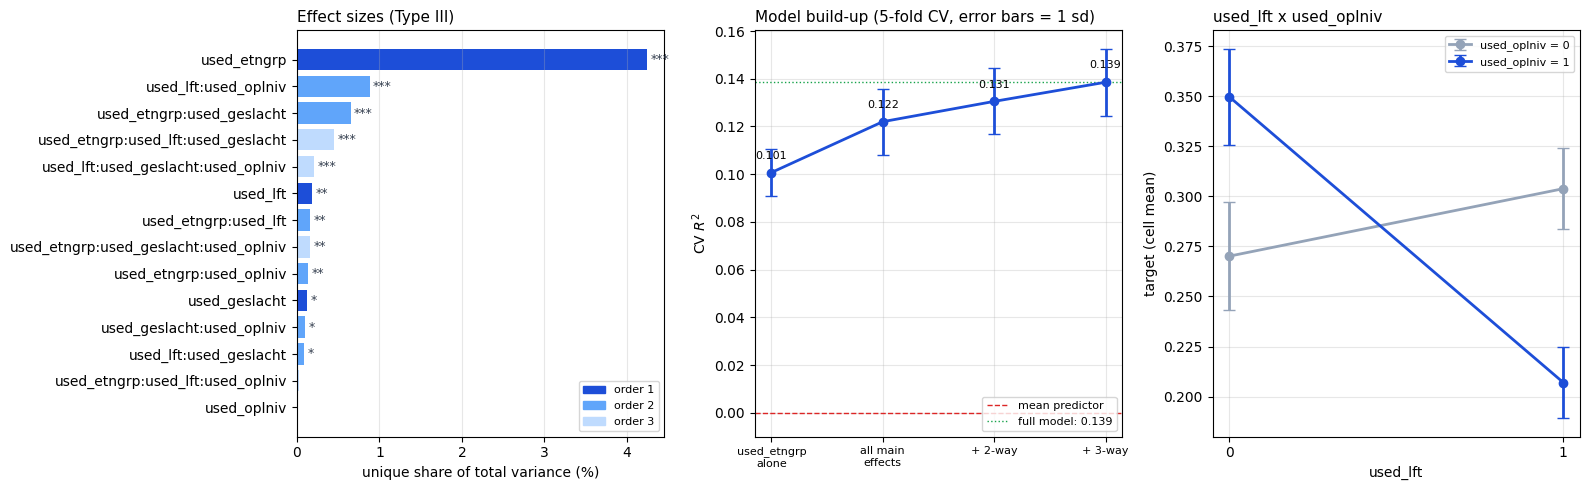

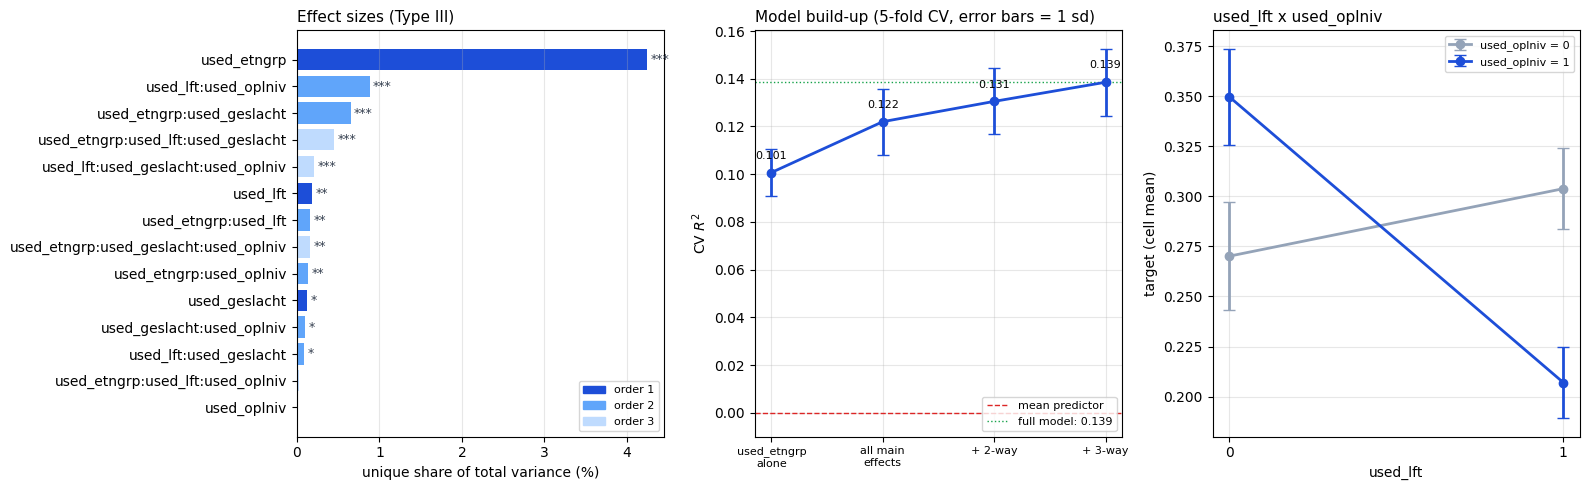

In [92]:
make_figure(sl[[f"used_{a}" for a in ATTRS]], sl[TARGET_COL],
            pd.DataFrame(res["effects"]), "used_lft", "used_oplniv",
            bdir / "design_effects.png")